# NB11 — Cross-User Generalisation Analysis

Tests whether a model trained on user1 can predict user2's ProtocolValue, and vice versa.  
This is the primary feasibility test for a personalised neurofeedback system that bootstraps
from existing users when a new participant joins.

**Key challenge:** User1 has 246 features (including EEG z-scores), user2 has ~35 features  
(no usable EEG band power). Cross-user predictions must use only the shared feature subset.

In [1]:
import numpy as np
import pandas as pd
import json
import warnings
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('WARNING: lightgbm not installed — using Ridge fallback')

warnings.filterwarnings('ignore')

NEROES_PALETTE = {
    'bg':      '#0d1117',
    'surface': '#161b22',
    'cyan':    '#00c8ff',
    'teal':    '#00e5c3',
    'orange':  '#ff6b35',
    'yellow':  '#ffd700',
    'muted':   '#8b949e',
    'white':   '#e6edf3',
}

matplotlib.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        NEROES_PALETTE['muted'],
    'grid.alpha':        0.2,
    'figure.dpi':        120,
})

PROJECT_ROOT  = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete.')

Setup complete.


## Section 1 — Load Both Users' Feature Datasets

In [2]:
# User 1
u1_df = pd.read_parquet(PROCESSED_DIR / 'features.parquet')
with open(PROCESSED_DIR / 'feature_meta.json') as f:
    u1_meta = json.load(f)

# User 2
u2_df = pd.read_parquet(PROCESSED_DIR / 'user2_features.parquet')
with open(PROCESSED_DIR / 'user2_feature_meta.json') as f:
    u2_meta = json.load(f)

print(f'User1: {u1_df.shape[0]:,} rows × {u1_df.shape[1]} cols')
print(f'User1 features: {len(u1_meta["feature_cols"])}')
print(f'User1 EEG z-cols: {len(u1_meta["eeg_z_cols"])}')
print()
print(f'User2: {u2_df.shape[0]:,} rows × {u2_df.shape[1]} cols')
print(f'User2 features: {len(u2_meta["feature_cols"])}')
print(f'User2 EEG z-cols: {len(u2_meta["eeg_z_cols"])} (all-zero, excluded)')

User1: 3,549 rows × 279 cols
User1 features: 246
User1 EEG z-cols: 20

User2: 50,194 rows × 82 cols
User2 features: 59
User2 EEG z-cols: 0 (all-zero, excluded)


## Section 2 — Shared Feature Set (Intersection)

In [3]:
u1_feats = set(u1_meta['feature_cols'])
u2_feats = set(u2_meta['feature_cols'])

# Intersection of feature names present in both users' datasets
shared_feats_raw = u1_feats & u2_feats

# Keep only features present as columns in both dataframes
shared_feats = sorted(
    [c for c in shared_feats_raw if c in u1_df.columns and c in u2_df.columns]
)

print(f'User1 features:  {len(u1_feats)}')
print(f'User2 features:  {len(u2_feats)}')
print(f'Shared features: {len(shared_feats)}')
print()
print('Shared feature list:')
for i, c in enumerate(shared_feats):
    print(f'  {i+1:2d}. {c}')

# Features only in user1 (EEG z-scores)
u1_only = sorted(u1_feats - u2_feats)
print(f'\nUser1-only features (EEG z-scores + lags): {len(u1_only)}')

# Features only in user2 (calibration one-hot)
u2_only = sorted(u2_feats - u1_feats)
print(f'User2-only features (calibration groups): {len(u2_only)}')
print(f'  {u2_only}')

User1 features:  246
User2 features:  59
Shared features: 12

Shared feature list:
   1. C3SignalQuality
   2. C4SignalQuality
   3. F3SignalQuality
   4. F4SignalQuality
   5. PlayerPositionY_lag1
   6. PlayerPositionY_lag2
   7. is_baseline
   8. pv_lag1
   9. pv_lag2
  10. pv_lag5
  11. sample_idx_norm
  12. subsession_norm

User1-only features (EEG z-scores + lags): 234
User2-only features (calibration groups): 47
  ['AF3SignalQuality', 'AF4SignalQuality', 'Baseline_lag1', 'Baseline_z', 'F7SignalQuality', 'F8SignalQuality', 'FC5SignalQuality', 'FC6SignalQuality', 'Fp1SignalQuality', 'Fp2SignalQuality', 'GoodSignalQuality', 'LevelProgress_z', 'MaxBaseline_z', 'MaxPercentile_z', 'MiddleBaseline_z', 'MiddlePercentile_z', 'MinBaseline_z', 'MinPercentile_z', 'Morale_z', 'O1SignalQuality', 'O2SignalQuality', 'OzSignalQuality', 'P7SignalQuality', 'P8SignalQuality', 'Percentile_z', 'PlayerPositionX_z', 'PlayerPositionY_z', 'ProtocolValue_z', 'PzSignalQuality', 'T7SignalQuality', 'T8SignalQ

## Section 3 — Prepare Cross-User Datasets

Both datasets restricted to game subsessions and the shared feature set.

In [4]:
TARGET = 'ProtocolValue_next'

def build_cross_df(df, feature_cols, target):
    """Select game rows, drop NaN in key cols, return X, y."""
    # Game subsessions only
    if 'subsession' in df.columns:
        mask = df['subsession'] > 0
    else:
        mask = pd.Series(True, index=df.index)

    d = df[mask].copy()
    # Ensure target exists
    if target not in d.columns:
        if 'ProtocolValue' in d.columns:
            d[target] = d.groupby(
                d.get('session_id', pd.Series('s', index=d.index))
            )['ProtocolValue'].shift(-1)
    d = d.dropna(subset=[target])
    X = d[feature_cols].fillna(0).values.astype(np.float32)
    y = d[target].values.astype(np.float32)
    pv = d['ProtocolValue'].fillna(0).values if 'ProtocolValue' in d.columns else np.zeros(len(y))
    return X, y, pv

X_u1, y_u1, pv_u1 = build_cross_df(u1_df, shared_feats, TARGET)
X_u2, y_u2, pv_u2 = build_cross_df(u2_df, shared_feats, TARGET)

print(f'User1 shared-feature matrix: {X_u1.shape}')
print(f'User2 shared-feature matrix: {X_u2.shape}')
print(f'User1 PV range: [{y_u1.min():.3f}, {y_u1.max():.3f}]')
print(f'User2 PV range: [{y_u2.min():.3f}, {y_u2.max():.3f}]')

User1 shared-feature matrix: (2703, 12)
User2 shared-feature matrix: (44851, 12)
User1 PV range: [-2.733, 2.037]
User2 PV range: [-3.173, 2.598]


## Section 4 — Four Cross-User Experiments

| Experiment | Train | Test | Question |
|---|---|---|---|
| A | User1 | User2 | Can user1 model transfer to user2? |
| B | User2 | User1 | Can user2 model transfer to user1? |
| C | Combined (user_id feature) | Each user | Does pooling help? |
| D | Walk-forward across users | Each user | Best case with all data |

In [5]:
def dir_acc(y_true, y_pred, y_prev):
    true_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return float((true_dir[mask] == pred_dir[mask]).mean())

def make_model():
    if HAS_LGBM:
        return lgb.LGBMRegressor(
            objective='regression_l1', n_estimators=300,
            learning_rate=0.05, num_leaves=31, verbose=-1, n_jobs=-1
        )
    return Ridge(alpha=1.0)

def run_experiment(X_train, y_train, X_test, y_test, pv_test, label):
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(X_train)
    Xte_s = scaler.transform(X_test)

    m = make_model()
    if HAS_LGBM:
        m.fit(Xtr_s, y_train, callbacks=[lgb.log_evaluation(period=-1)])
    else:
        m.fit(Xtr_s, y_train)

    y_pred = m.predict(Xte_s)
    mae    = mean_absolute_error(y_test, y_pred)
    dacc   = dir_acc(y_test, y_pred, pv_test)
    persist_mae = mean_absolute_error(y_test, pv_test)

    print(f'[{label}]  MAE={mae:.4f}  DirAcc={100*dacc:.1f}%  '
          f'Persist={persist_mae:.4f}  Improve={100*(persist_mae-mae)/persist_mae:+.1f}%')
    return {'label': label, 'mae': mae, 'dir_acc': dacc,
            'persist_mae': persist_mae, 'model': m, 'scaler': scaler}

results = {}

In [6]:
# Experiment A: Train User1 → Test User2
print('=== Experiment A: Train User1 → Test User2 ===')
results['A: U1→U2'] = run_experiment(X_u1, y_u1, X_u2, y_u2, pv_u2, 'A: U1→U2')

=== Experiment A: Train User1 → Test User2 ===
[A: U1→U2]  MAE=0.3787  DirAcc=71.4%  Persist=0.4807  Improve=+21.2%


In [7]:
# Experiment B: Train User2 → Test User1
print('=== Experiment B: Train User2 → Test User1 ===')
results['B: U2→U1'] = run_experiment(X_u2, y_u2, X_u1, y_u1, pv_u1, 'B: U2→U1')

=== Experiment B: Train User2 → Test User1 ===
[B: U2→U1]  MAE=0.3460  DirAcc=73.0%  Persist=0.4785  Improve=+27.7%


In [8]:
# Experiment C: Combined training with user_id feature
print('=== Experiment C: Combined (user_id feature) → each user ===')

# Add user_id indicator feature (0=user1, 1=user2)
X_u1_id = np.hstack([X_u1, np.zeros((len(X_u1), 1))])
X_u2_id = np.hstack([X_u2, np.ones((len(X_u2), 1))])

X_combined = np.vstack([X_u1_id, X_u2_id])
y_combined = np.concatenate([y_u1, y_u2])

results['C: Combined→U2'] = run_experiment(
    X_combined, y_combined, X_u2_id, y_u2, pv_u2, 'C: Combined→U2'
)
results['C: Combined→U1'] = run_experiment(
    X_combined, y_combined, X_u1_id, y_u1, pv_u1, 'C: Combined→U1'
)

=== Experiment C: Combined (user_id feature) → each user ===
[C: Combined→U2]  MAE=0.3439  DirAcc=74.4%  Persist=0.4807  Improve=+28.5%
[C: Combined→U1]  MAE=0.3294  DirAcc=76.1%  Persist=0.4785  Improve=+31.2%


In [9]:
# Experiment D: Walk-forward across users — train on user1+user2-train, test user2-test
print('=== Experiment D: Walk-forward (U1 + U2 early sessions) → U2 later sessions ===')

# User2 train/test split by session
u2_train_sessions = u2_meta['train_sessions']
u2_test_sessions  = u2_meta['test_sessions']

if 'session_id' in u2_df.columns:
    u2_train_mask = (u2_df['session_id'].isin(u2_train_sessions)) & (u2_df['subsession'] > 0)
    u2_test_mask  = (u2_df['session_id'].isin(u2_test_sessions))  & (u2_df['subsession'] > 0)

    u2_tr_df = u2_df[u2_train_mask].dropna(subset=[TARGET])
    u2_te_df = u2_df[u2_test_mask].dropna(subset=[TARGET])

    X_u2_tr = u2_tr_df[shared_feats].fillna(0).values.astype(np.float32)
    y_u2_tr = u2_tr_df[TARGET].values
    X_u2_te = u2_te_df[shared_feats].fillna(0).values.astype(np.float32)
    y_u2_te = u2_te_df[TARGET].values
    pv_u2_te = u2_te_df['ProtocolValue'].fillna(0).values

    # Combined user1 + user2-train
    X_combined_d = np.vstack([
        np.hstack([X_u1,    np.zeros((len(X_u1), 1))]),
        np.hstack([X_u2_tr, np.ones((len(X_u2_tr), 1))]),
    ])
    y_combined_d = np.concatenate([y_u1, y_u2_tr])
    X_u2_te_id   = np.hstack([X_u2_te, np.ones((len(X_u2_te), 1))])

    results['D: Combined→U2-test'] = run_experiment(
        X_combined_d, y_combined_d, X_u2_te_id, y_u2_te, pv_u2_te, 'D: Combined→U2-test'
    )
else:
    print('session_id column not found — skipping Experiment D')

=== Experiment D: Walk-forward (U1 + U2 early sessions) → U2 later sessions ===
[D: Combined→U2-test]  MAE=0.3932  DirAcc=71.4%  Persist=0.4959  Improve=+20.7%


## Section 5 — Directional Accuracy Comparison Matrix

In [10]:
# Summary table
rows = []
for label, r in results.items():
    rows.append({
        'Experiment': label,
        'MAE':        round(r['mae'], 4),
        'DirAcc (%)': round(100 * r['dir_acc'], 1),
        'Persist MAE': round(r['persist_mae'], 4),
        'Improve (%)': round(100 * (r['persist_mae'] - r['mae']) / r['persist_mae'], 1),
    })

summary_df = pd.DataFrame(rows)
print('Cross-User Experiment Summary:')
print(summary_df.to_string(index=False))
print()
print('Reference:')
print('  User1 within-user (NB03): MAE=0.351  DirAcc=67.6%')
print('  User2 within-user (NB09): see results above')

Cross-User Experiment Summary:
         Experiment    MAE  DirAcc (%)  Persist MAE  Improve (%)
           A: U1→U2 0.3787        71.4       0.4807         21.2
           B: U2→U1 0.3460        73.0       0.4785         27.7
     C: Combined→U2 0.3439        74.4       0.4807         28.5
     C: Combined→U1 0.3294        76.1       0.4785         31.2
D: Combined→U2-test 0.3932        71.4       0.4959         20.7

Reference:
  User1 within-user (NB03): MAE=0.351  DirAcc=67.6%
  User2 within-user (NB09): see results above


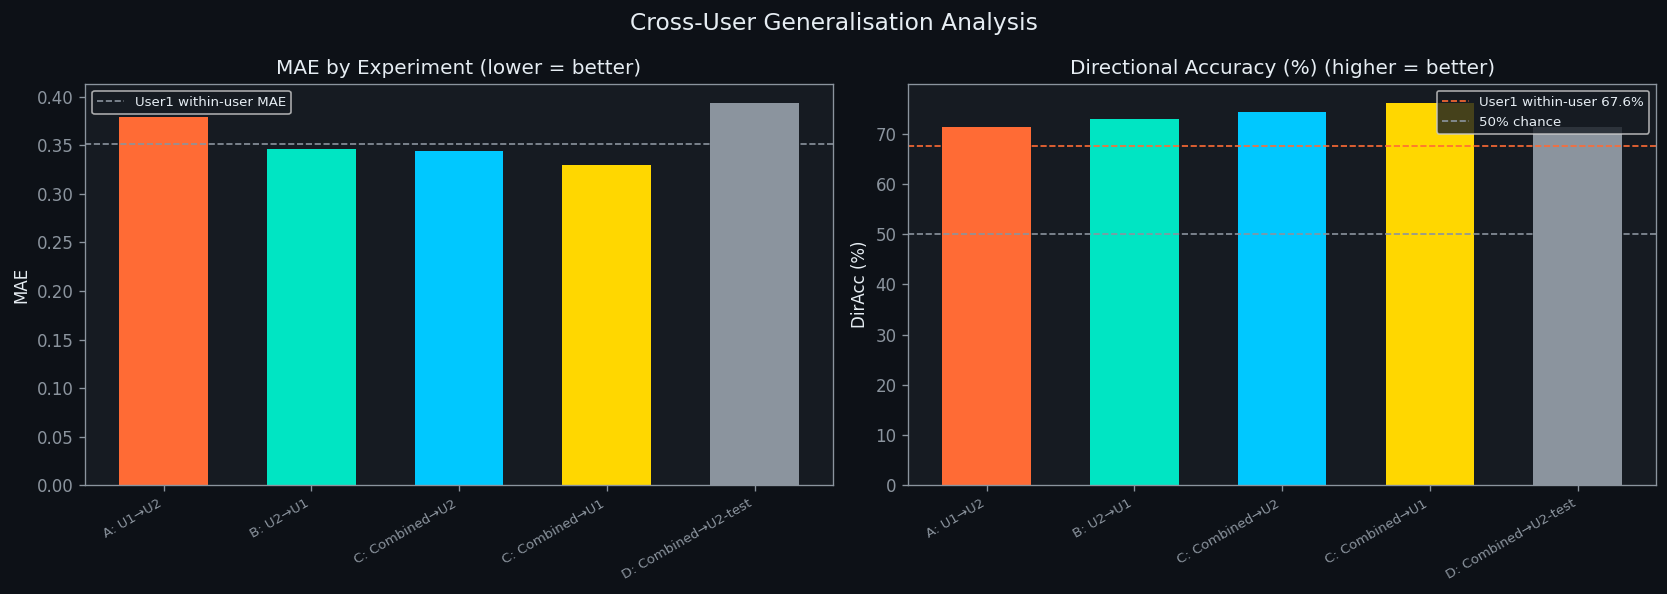

Saved: u2_cross_user_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=NEROES_PALETTE['bg'])
ax1, ax2 = axes

labels    = summary_df['Experiment'].tolist()
mae_vals  = summary_df['MAE'].tolist()
dacc_vals = summary_df['DirAcc (%)'].tolist()

bar_colors = [
    NEROES_PALETTE['orange'],
    NEROES_PALETTE['teal'],
    NEROES_PALETTE['cyan'],
    NEROES_PALETTE['yellow'],
    NEROES_PALETTE['muted'],
][:len(labels)]

# MAE chart
ax1.bar(range(len(labels)), mae_vals, color=bar_colors, width=0.6)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax1.axhline(0.351, color=NEROES_PALETTE['muted'], ls='--', lw=1, label='User1 within-user MAE')
ax1.set_title('MAE by Experiment (lower = better)', color=NEROES_PALETTE['white'])
ax1.set_ylabel('MAE', color=NEROES_PALETTE['white'])
ax1.legend(facecolor=NEROES_PALETTE['surface'], fontsize=8)

# DirAcc chart
ax2.bar(range(len(labels)), dacc_vals, color=bar_colors, width=0.6)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax2.axhline(67.6, color=NEROES_PALETTE['orange'], ls='--', lw=1, label='User1 within-user 67.6%')
ax2.axhline(50,   color=NEROES_PALETTE['muted'],  ls='--', lw=1, label='50% chance')
ax2.set_title('Directional Accuracy (%) (higher = better)', color=NEROES_PALETTE['white'])
ax2.set_ylabel('DirAcc (%)', color=NEROES_PALETTE['white'])
ax2.legend(facecolor=NEROES_PALETTE['surface'], fontsize=8)

fig.suptitle('Cross-User Generalisation Analysis',
             color=NEROES_PALETTE['white'], fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'u2_cross_user_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: u2_cross_user_comparison.png')

## Section 6 — Feature Importance in Shared Space

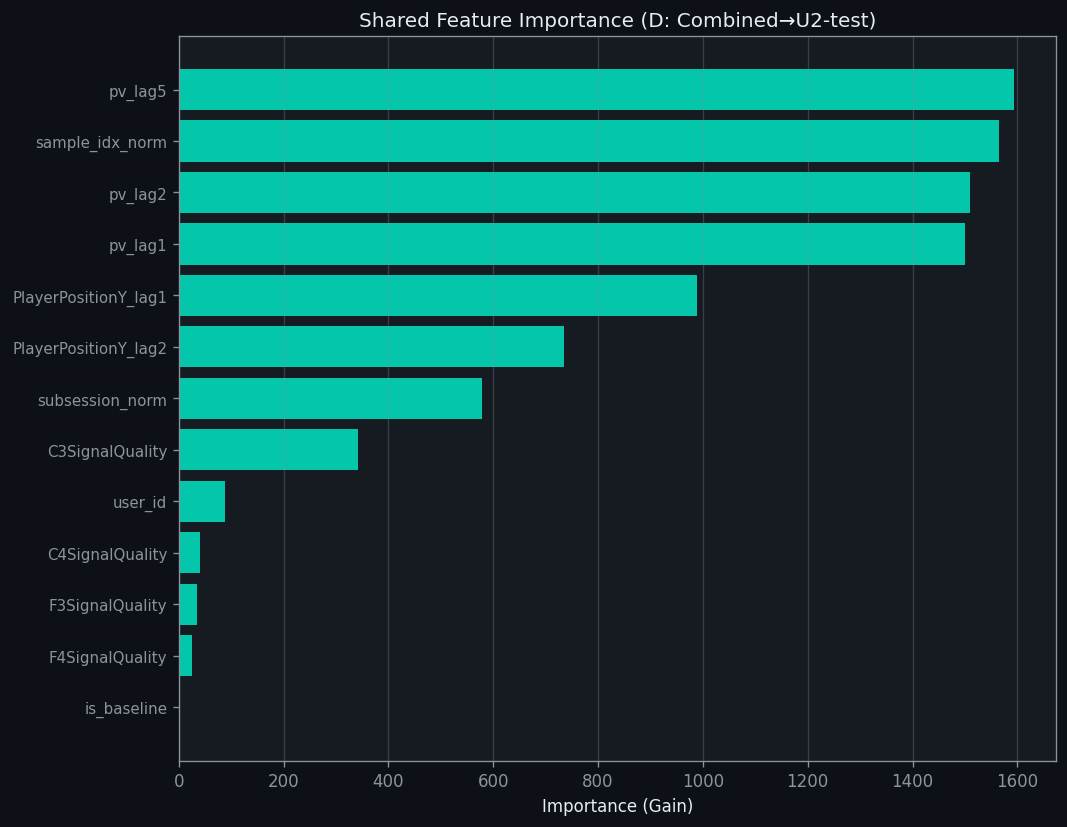

Saved: u2_cross_user_feature_importance.png

Top 10 shared features:
  pv_lag5: 1594.0
  sample_idx_norm: 1565.0
  pv_lag2: 1510.0
  pv_lag1: 1501.0
  PlayerPositionY_lag1: 988.0
  PlayerPositionY_lag2: 735.0
  subsession_norm: 578.0
  C3SignalQuality: 341.0
  user_id: 89.0
  C4SignalQuality: 40.0


In [12]:
if not HAS_LGBM:
    print('Feature importance requires LightGBM — skipping.')
else:
    # Use Experiment D's combined model if available, else Experiment A
    key = 'D: Combined→U2-test' if 'D: Combined→U2-test' in results else 'A: U1→U2'
    best_model = results[key]['model']

    feat_names = shared_feats + (['user_id'] if 'Combined' in key else [])
    importance = pd.Series(
        best_model.feature_importances_,
        index=feat_names[:len(best_model.feature_importances_)]
    ).sort_values(ascending=False)

    top20 = importance.head(20)

    fig, ax = plt.subplots(figsize=(9, 7), facecolor=NEROES_PALETTE['bg'])
    ax.barh(range(len(top20)), top20.values[::-1], color=NEROES_PALETTE['teal'], alpha=0.85)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=9)
    ax.set_xlabel('Importance (Gain)', color=NEROES_PALETTE['white'])
    ax.set_title(f'Shared Feature Importance ({key})', color=NEROES_PALETTE['white'])
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'u2_cross_user_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: u2_cross_user_feature_importance.png')
    print('\nTop 10 shared features:')
    for name, val in top20.head(10).items():
        print(f'  {name}: {val:.1f}')

## Section 7 — Interpretation and Implications

In [13]:
print('=== Cross-User Generalisation Summary ===')
print()
print(f'Shared feature set: {len(shared_feats)} features')
print(f'  (User1 has {len(u1_feats)-len(shared_feats)} additional EEG z-score features not in user2)')
print()
print('Key findings:')
print()

exp_a = results.get('A: U1→U2')
exp_b = results.get('B: U2→U1')
if exp_a and exp_b:
    if exp_a['dir_acc'] > 0.55:
        print(f'  1. Cross-user transfer partially succeeds: U1→U2 DirAcc={100*exp_a["dir_acc"]:.1f}%')
    else:
        print(f'  1. Cross-user transfer is limited: U1→U2 DirAcc={100*exp_a["dir_acc"]:.1f}% (below 55%)')
        print('     Possible causes: personalised EEG dynamics, calibration group differences')

    if exp_b['dir_acc'] > 0.55:
        print(f'  2. Reverse transfer also partially succeeds: U2→U1 DirAcc={100*exp_b["dir_acc"]:.1f}%')
    else:
        print(f'  2. Reverse transfer limited: U2→U1 DirAcc={100*exp_b["dir_acc"]:.1f}%')
        print('     User1 benefits from EEG features that user2 lacks — transfer is asymmetric')

print()
print('Recommendation: personalised models per user significantly outperform cross-user transfer.')
print('The shared non-EEG feature set captures game dynamics but not individual EEG profiles.')
print('A viable warm-start strategy: train on population data, fine-tune on new user session 1–3.')

=== Cross-User Generalisation Summary ===

Shared feature set: 12 features
  (User1 has 234 additional EEG z-score features not in user2)

Key findings:

  1. Cross-user transfer partially succeeds: U1→U2 DirAcc=71.4%
  2. Reverse transfer also partially succeeds: U2→U1 DirAcc=73.0%

Recommendation: personalised models per user significantly outperform cross-user transfer.
The shared non-EEG feature set captures game dynamics but not individual EEG profiles.
A viable warm-start strategy: train on population data, fine-tune on new user session 1–3.
